# 📐 Notebook 2: False-Positive Rates and Sizing

In notebook 1 we built a bloom filter but picked `m` and `k` out of thin air. In practice you start from the **requirements**:

- *"I expect to store up to **n = 1,000,000** items."*
- *"I can tolerate a false-positive rate of **p = 1%**."*

Then math tells you the optimal `m` (bits) and `k` (hashes).

## Learning objectives
- Learn the formulas for optimal `m` and `k`.
- Build intuition with a plot: FPR vs number of items inserted.
- Empirically verify the theory with a Monte Carlo simulation.

## 🛠️ Setup

Run `uv sync` in the lab folder if you haven't already, then pick the `.venv` kernel.

If the kernel does not appear: `Cmd+Shift+P` → **Reload Window**.

## 📏 The formulas

Given:
- `n` — number of items you expect to insert
- `p` — acceptable false-positive probability (e.g. `0.01` for 1%)

The optimal settings are:

$$ m = -\frac{n \ln p}{(\ln 2)^2} \quad\text{(bits)} $$

$$ k = \frac{m}{n} \ln 2 \quad\text{(number of hash functions)} $$

And after inserting `n` items, the theoretical false-positive probability is:

$$ p \approx \left(1 - e^{-kn/m}\right)^{k} $$

You do **not** need to memorize these. Just remember: **more bits → fewer false positives**, and for a fixed number of bits, there is an optimal number of hashes — too few and you miss information, too many and you fill bits too fast.

In [1]:
import math
from pydantic import BaseModel, Field

class BloomParams(BaseModel):
    """Optimal sizing for a bloom filter given expected n and target FPR."""
    n: int = Field(gt=0, description="expected number of items")
    p: float = Field(gt=0, lt=1, description="target false-positive probability")

    @property
    def m(self) -> int:
        """optimal number of bits"""
        return int(math.ceil(-self.n * math.log(self.p) / (math.log(2) ** 2)))

    @property
    def k(self) -> int:
        """optimal number of hash functions"""
        return max(1, int(round((self.m / self.n) * math.log(2))))

    def theoretical_fpr(self) -> float:
        return (1 - math.exp(-self.k * self.n / self.m)) ** self.k


# Example: 1 million items, 1% FPR
params = BloomParams(n=1_000_000, p=0.01)
print(f"n = {params.n:,} items, target FPR = {params.p:.1%}")
print(f"→ m = {params.m:,} bits  ({params.m/8/1024:.1f} KB)")
print(f"→ k = {params.k} hash functions")
print(f"→ theoretical FPR at full load: {params.theoretical_fpr():.4%}")

n = 1,000,000 items, target FPR = 1.0%
→ m = 9,585,059 bits  (1170.1 KB)
→ k = 7 hash functions
→ theoretical FPR at full load: 1.0039%


### Rule of thumb worth remembering

For a **1% false-positive rate**, a bloom filter needs roughly **~10 bits per item**. For **0.1%**, about **~15 bits per item**. Compare that to storing a 60-byte URL (= 480 bits): **~50× smaller**.

In [2]:
for p in [0.1, 0.01, 0.001, 0.0001]:
    pr = BloomParams(n=1_000_000, p=p)
    bits_per_item = pr.m / pr.n
    print(f"FPR={p:<8}  m={pr.m:>10,} bits  k={pr.k:<2}  ~{bits_per_item:.1f} bits/item")

FPR=0.1       m= 4,792,530 bits  k=3   ~4.8 bits/item
FPR=0.01      m= 9,585,059 bits  k=7   ~9.6 bits/item
FPR=0.001     m=14,377,588 bits  k=10  ~14.4 bits/item
FPR=0.0001    m=19,170,117 bits  k=13  ~19.2 bits/item


## 🧪 Empirical verification

Theory is nice, but let's **actually measure** the false-positive rate and compare it to the formula.

We'll re-use the `BloomFilter` class from notebook 1 (copied here so this notebook stands alone).

In [3]:
import hashlib

class BloomFilter:
    def __init__(self, m: int, k: int):
        self.m, self.k = m, k
        self.bits = bytearray((m + 7) // 8)

    def _set_bit(self, i):
        self.bits[i // 8] |= 1 << (i % 8)

    def _get_bit(self, i):
        return (self.bits[i // 8] >> (i % 8)) & 1

    def _positions(self, item: str):
        d = hashlib.sha256(item.encode()).digest()
        h1 = int.from_bytes(d[:8], 'big')
        h2 = int.from_bytes(d[8:16], 'big')
        for i in range(self.k):
            yield (h1 + i * h2) % self.m

    def add(self, item: str):
        for p in self._positions(item):
            self._set_bit(p)

    def __contains__(self, item: str):
        return all(self._get_bit(p) for p in self._positions(item))

print("BloomFilter ready")

BloomFilter ready


In [4]:
import random

def make_items(n, prefix):
    return [f"{prefix}-{i}" for i in range(n)]

def measure_fpr(bf: BloomFilter, inserted, probes):
    inserted_set = set(inserted)
    true_negatives = [x for x in probes if x not in inserted_set]
    fp = sum(1 for x in true_negatives if x in bf)
    return fp / len(true_negatives) if true_negatives else 0.0

# Configure for n=10_000, target FPR=1%
params = BloomParams(n=10_000, p=0.01)
print(f"m={params.m:,} bits, k={params.k}, theoretical FPR={params.theoretical_fpr():.4%}")

bf = BloomFilter(m=params.m, k=params.k)
inserted = make_items(params.n, "inserted")
for x in inserted:
    bf.add(x)

probes = make_items(100_000, "probe")  # disjoint prefix => all true negatives
fpr = measure_fpr(bf, inserted, probes)
print(f"Measured FPR after inserting all {params.n:,} items: {fpr:.4%}")

m=95,851 bits, k=7, theoretical FPR=1.0039%
Measured FPR after inserting all 10,000 items: 1.0150%


The measured value should be very close to the theoretical one. Any small difference is just Monte Carlo noise.

## 📈 FPR vs items inserted (watch it fill up)

A bloom filter is only "1% FPR" when it's been filled to capacity `n`. Before that, FPR is much lower; after that, it gets worse. Let's plot it.

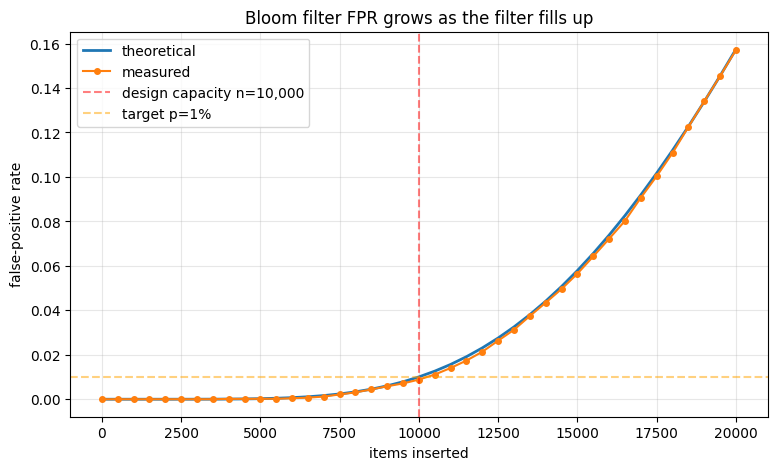

In [5]:
import matplotlib.pyplot as plt

params = BloomParams(n=10_000, p=0.01)
bf = BloomFilter(m=params.m, k=params.k)

probes = make_items(20_000, "probe")
inserted = make_items(params.n * 2, "inserted")  # go past capacity

checkpoints = list(range(0, len(inserted) + 1, 500))
measured, theoretical = [], []

idx = 0
for cp in checkpoints:
    while idx < cp:
        bf.add(inserted[idx])
        idx += 1
    measured.append(measure_fpr(bf, inserted[:cp], probes))
    n_so_far = max(1, cp)
    # theoretical with actual n_so_far items
    import math
    theoretical.append((1 - math.exp(-params.k * n_so_far / params.m)) ** params.k)

plt.figure(figsize=(9, 5))
plt.plot(checkpoints, theoretical, label="theoretical", linewidth=2)
plt.plot(checkpoints, measured, 'o-', label="measured", markersize=4)
plt.axvline(params.n, color='red', linestyle='--', alpha=0.5, label=f'design capacity n={params.n:,}')
plt.axhline(params.p, color='orange', linestyle='--', alpha=0.5, label=f'target p={params.p:.0%}')
plt.xlabel('items inserted')
plt.ylabel('false-positive rate')
plt.title('Bloom filter FPR grows as the filter fills up')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### What the plot shows

- At the start, FPR is ~0 — most bits are still 0.
- Around the designed capacity (`n = 10,000`), FPR crosses the target 1% line — exactly as the formula predicts.
- If you keep inserting past capacity, FPR degrades quickly. This is why bloom filter sizing is so important: **pick `m` and `k` for the maximum `n` you'll ever need**.

## 🎓 Takeaways

1. Given a target FPR `p` and expected item count `n`, use the formulas to pick `m` and `k`.
2. Rule of thumb: ~10 bits per item for 1% FPR.
3. A bloom filter degrades once you exceed capacity — size for the worst case.
4. Want to be able to *grow* the filter? Look up **scalable bloom filters** (a chain of filters of increasing size). Want to *delete*? Look up **counting bloom filters** (each position is a small counter instead of a single bit).